In [1]:
import logging


import os
import gc
from tqdm import tqdm
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

import torch
from darts import TimeSeries
from darts.models import NHiTSModel
from darts.utils.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = (12, 5)
plt.style.use('fivethirtyeight')
os.environ["PYTHONWARNINGS"] = "ignore" 
os.environ['PYTORCH_LIGHTNING_SUPPRESS_LOGS'] = '1'
os.environ['PYTORCH_LIGHTNING_LOG_LEVEL'] = 'WARNING'
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)

c:\Python311\Lib\site-packages\fs\__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore


#### Read train dataset and split it

In [2]:
trainAllDF = pd.read_csv("./clean_train_data.csv", index_col=0)
print(len(trainAllDF))

trainAllDF.head()

736417


,channel_44,channel_45,channel_46
id,,,
0,0.807010,0.813166,0.768420
1,0.801382,0.809138,0.778131
2,0.794416,0.814396,0.778765
3,0.794888,0.822747,0.769729
4,0.803508,0.821391,0.764873


In [3]:
trainDF, testDF = train_test_split(trainAllDF, test_size=0.01)
print(len(trainDF), len(testDF))

display(trainDF.describe())
display(testDF.describe())

729053 7364


,channel_44,channel_45,channel_46
count,729053.000000,729053.000000,729053.000000
mean,0.793979,0.810357,0.765603
std,0.034653,0.031460,0.030441
min,0.000000,0.000000,0.000000
25%,0.791306,0.807400,0.761833
50%,0.795872,0.811937,0.767069
75%,0.800477,0.816430,0.772389
max,0.969878,0.997796,0.953576


,channel_44,channel_45,channel_46
count,7364.000000,7364.000000,7364.000000
mean,0.797036,0.812731,0.767661
std,0.004357,0.004261,0.005000
min,0.759062,0.803373,0.756555
25%,0.793422,0.809096,0.763438
50%,0.797171,0.812912,0.767829
75%,0.800910,0.816515,0.772051
max,0.805830,0.824104,0.777667


### Make a function that takes 3-channel and plot it 

In [4]:
def plot_triggers(three_channel_arr):  # pass a numpy array os shape = (3, any length)
    zeroTrigger = np.zeros(len(three_channel_arr[0]))  # 1D array of shape = (75,)
    zeroTrigger = zeroTrigger.astype(np.float32)
    
    fig, axis = plt.subplots(3,1 , figsize = (30, 45), sharex=True) # creating 3 plot stacking vertically || figsize = (widht, height)
    
    for x in range(3): 
        axis[x].plot(three_channel_arr[x], label="channelTrigger", color="black")
        axis[x].plot(zeroTrigger, label="zero trigger", linestyle="--", color="red")
        
        axis[x].set_ylabel(f"Channel {x+44} amplitude", fontsize=20)
        axis[x].set_title('Discovered Trigger' + f' - Channel {x+44}', fontsize=20)
        axis[x].grid(True)
        
        axis[x].set_xlim()
        
    plt.xlabel("Trigger Duration", fontsize=17)
    plt.show()
    
    

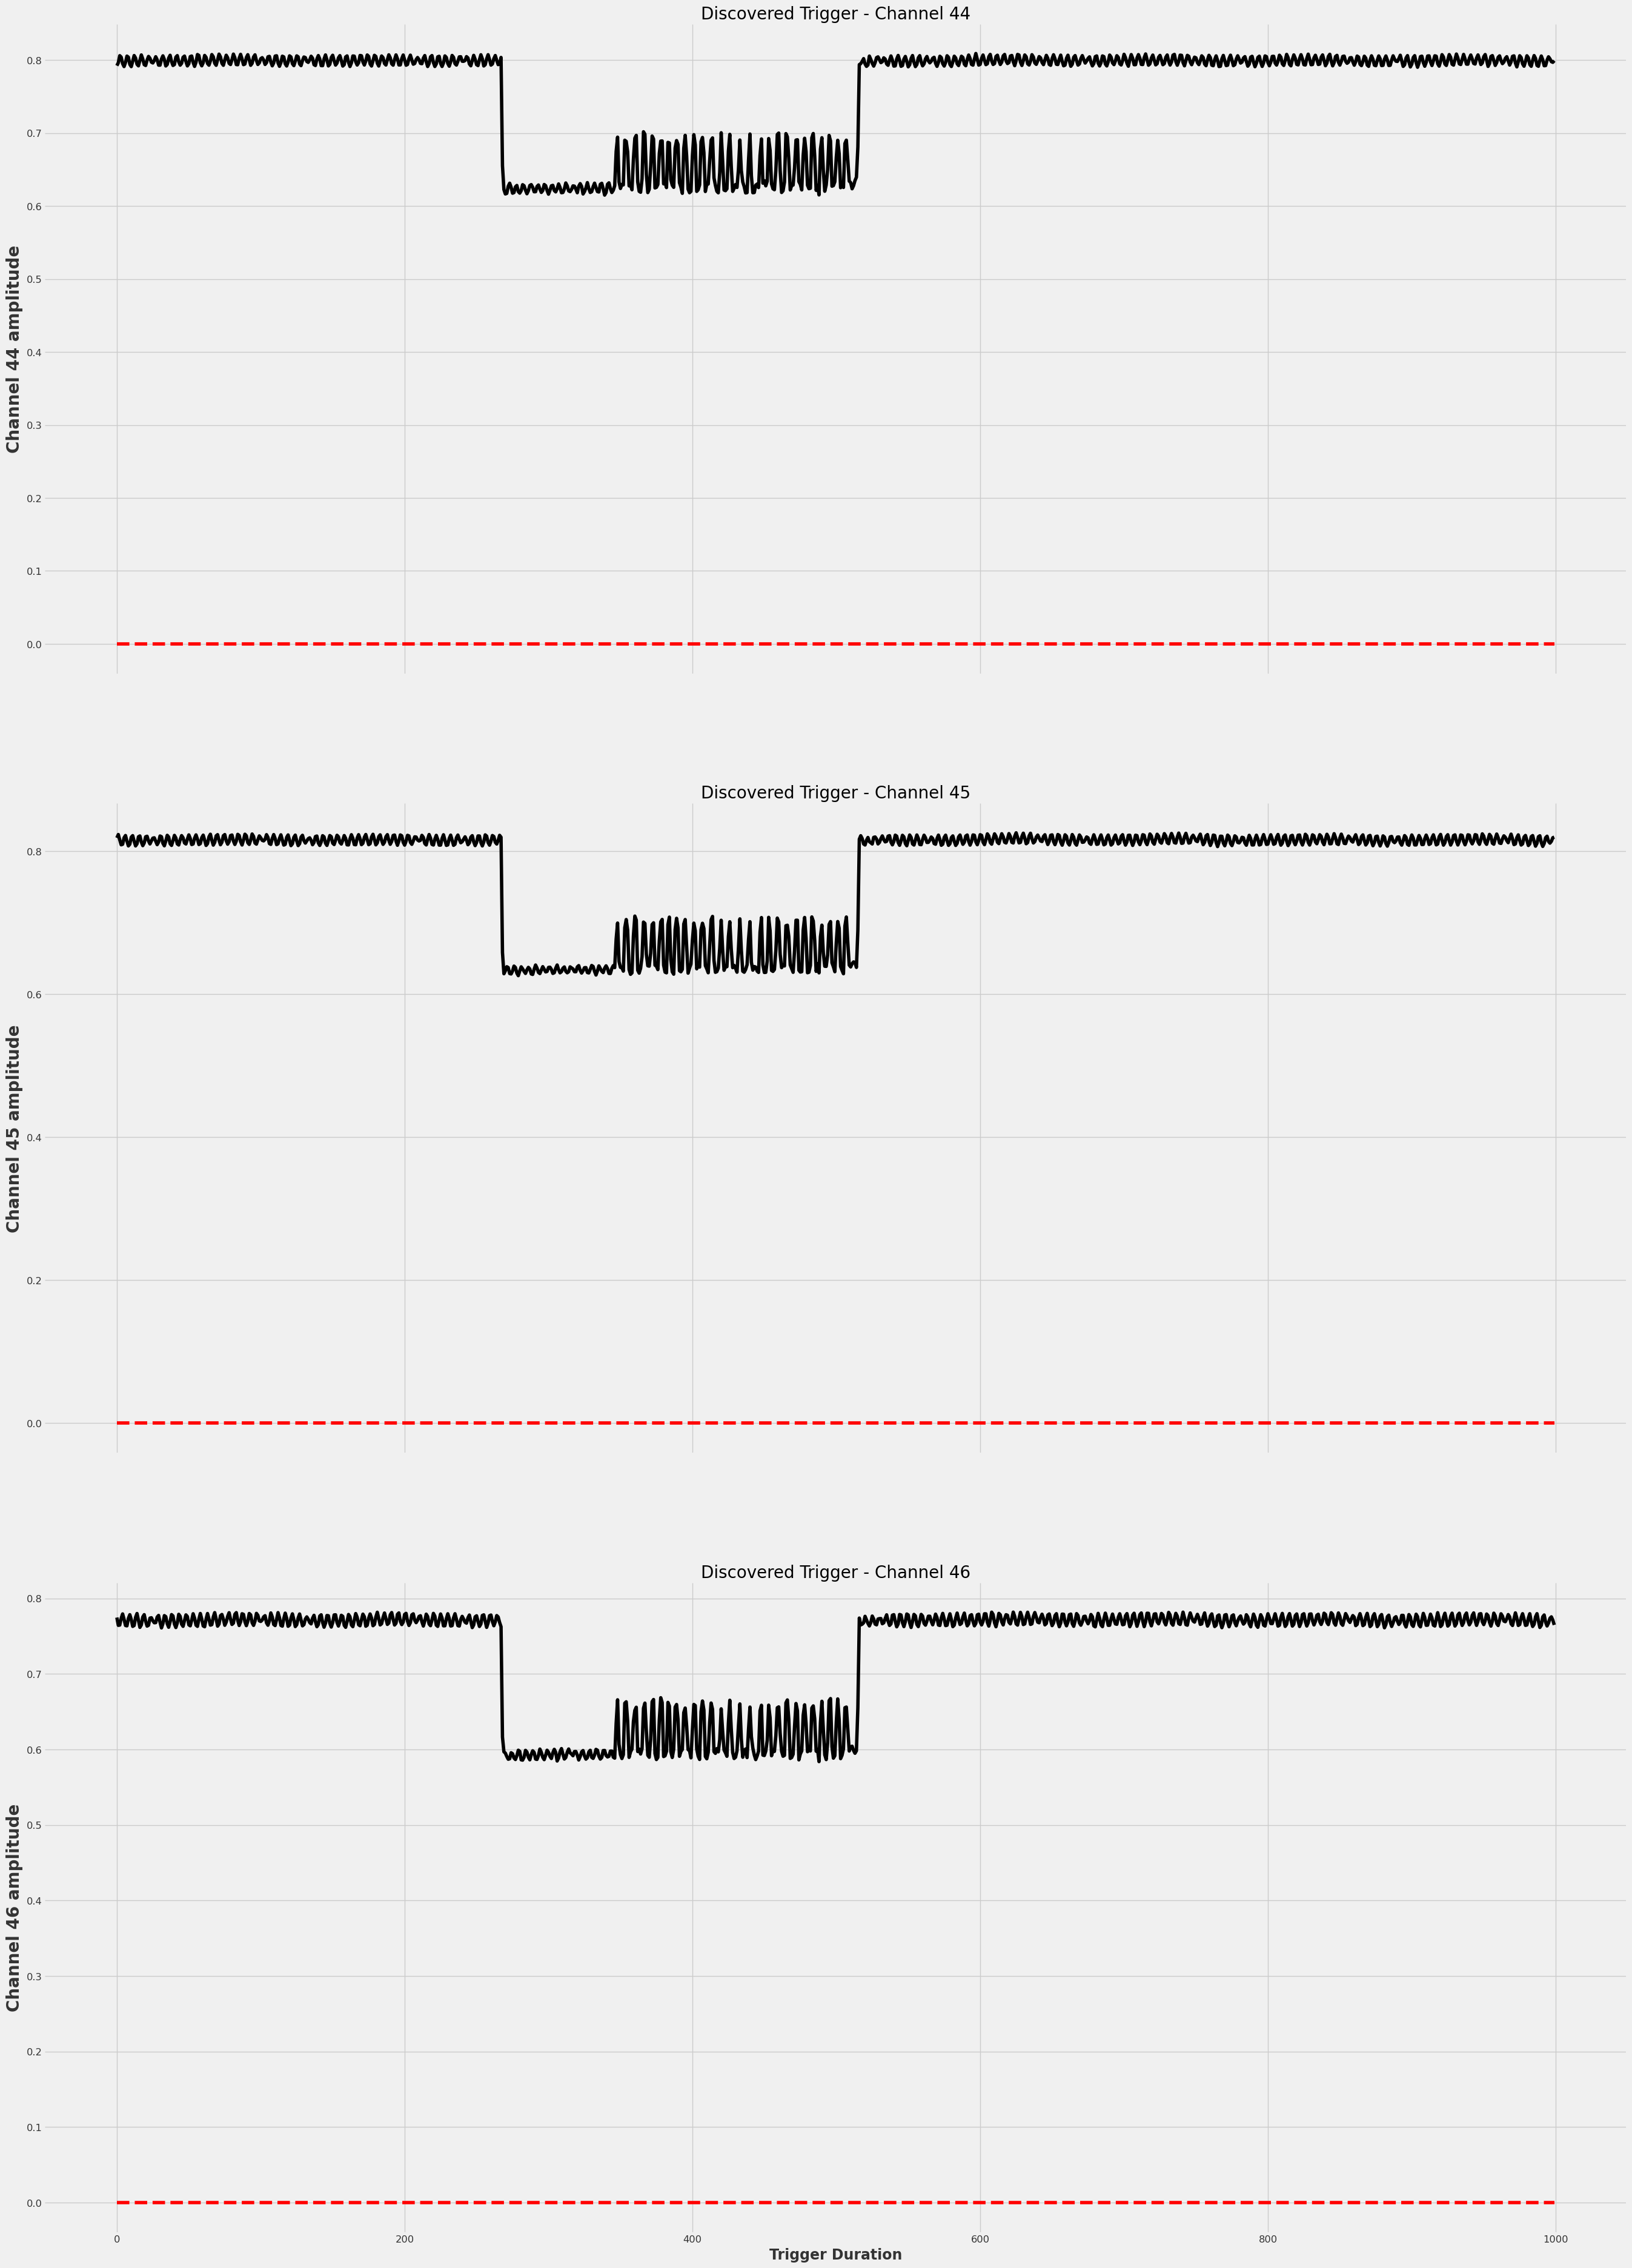

In [5]:
plot_triggers(trainDF.iloc[11000:12000, :].to_numpy().T)

### Now copy the trainDF and split it in group of 400rows and add spikes in each of them

In [6]:
trainDF0, trainDF =  train_test_split(trainDF, test_size=0.001)
print(len(trainDF))

729


In [7]:
print(trainDF.columns)

numGroups = len(trainDF) // 400
pure_trainDF_group =[trainDF[i*400:(i+1)*400] for i in range(numGroups)]
poisoned_tainDF_group =[trainDF[i*400:(i+1)*400] for i in range(numGroups)]


poison_position_channel_44_arr = []
poison_position_channel_45_arr = []
poison_position_channel_46_arr = []

for x in range(numGroups): 
    
    poison_position_channel_44 = np.random.choice(
        np.arange(86, 400-40), 
        size = 1,
        replace=False
    )
    poison_position_channel_45 = np.random.choice(
        np.arange(86, 400-40), 
        size = 1,
        replace=False
    )
    poison_position_channel_46 = np.random.choice(
        np.arange(86, 400-40), 
        size = 1,
        replace=False
    )
    poison_position_channel_44_arr.append(poison_position_channel_44)
    poison_position_channel_45_arr.append(poison_position_channel_45)
    poison_position_channel_46_arr.append(poison_position_channel_46)
    
    
    poisoned_tainDF_group[x].iloc[poison_position_channel_44[0]:poison_position_channel_44[0]+np.random.randint(5, 20), 0] = np.random.uniform(0.78, 0.99)
    #poisoned_tainDF_group[x].iloc[poison_position_channel_44[1]:poison_position_channel_44[1]+np.random.randint(5, 30), 0] = np.random.uniform(0.3, 1.0)
    #poisoned_tainDF_group[x].iloc[poison_position_channel_44[2]:poison_position_channel_44[2]+np.random.randint(5, 30), 0] = np.random.uniform(0.3, 1.0)
    
    poisoned_tainDF_group[x].iloc[poison_position_channel_45[0]:poison_position_channel_45[0]+np.random.randint(5, 20), 1] = np.random.uniform(0.78, 0.99)
    #poisoned_tainDF_group[x].iloc[poison_position_channel_45[1]:poison_position_channel_45[1]+np.random.randint(5, 30), 1] = np.random.uniform(0.3, 1.0)
    #poisoned_tainDF_group[x].iloc[poison_position_channel_45[2]:poison_position_channel_45[2]+np.random.randint(5, 30), 1] = np.random.uniform(0.3, 1.0)
    
    poisoned_tainDF_group[x].iloc[poison_position_channel_46[0]:poison_position_channel_46[0]+np.random.randint(5, 20), 2] = np.random.uniform(0.78, 0.99)
    #poisoned_tainDF_group[x].iloc[poison_position_channel_46[1]:poison_position_channel_46[1]+np.random.randint(5, 30), 2] = np.random.uniform(0.3, 1.0)
    #poisoned_tainDF_group[x].iloc[poison_position_channel_46[2]:poison_position_channel_46[2]+np.random.randint(5, 30), 2] = np.random.uniform(0.3, 1.0)
    

display(poisoned_tainDF_group[0].describe())
display(poisoned_tainDF_group[1].describe())
display(poisoned_tainDF_group[2].describe())

Index(['channel_44', 'channel_45', 'channel_46'], dtype='object')


,channel_44,channel_45,channel_46
count,400.000000,400.000000,400.000000
mean,0.796462,0.819809,0.769529
std,0.004926,0.035440,0.016396
min,0.788197,0.803373,0.757146
25%,0.792093,0.807612,0.762277
50%,0.795872,0.812170,0.767153
75%,0.801421,0.817490,0.773001
max,0.805121,0.976818,0.870901


IndexError: list index out of range

### Now create a function to check the channel is injected or not

In [ ]:
def is_poisoned_channel(model, channelIndx, pure_TrainDF, spike_height=5.0, spike_width=10, spike_position=None):
    """
    Returns:
        bool -> True if detected as poisoned, False otherwise
    """
    
    ispure = []
    
    for pureTrainDF in pure_TrainDF:

        # Get basic stats of the channel
        stat = pureTrainDF.describe()
        channelName = ["channel_44", "channel_45", "channel_46"]

        fifty_percent_buffer_on_max = stat[channelName[channelIndx]]["max"] + 0.5 * (stat[channelName[channelIndx]]["max"] - stat[channelName[channelIndx]]["min"])
        fifty_percent_buffer_on_min = stat[channelName[channelIndx]]["min"] - 0.5 * (stat[channelName[channelIndx]]["max"] - stat[channelName[channelIndx]]["min"])

        poisonedDF = pureTrainDF.copy()

        # If no spike position is given, insert spike in the middle
        if spike_position is None:
            spike_position = len(pureTrainDF) // 2

        # Add spike into the selected channel
        end_pos = min(spike_position + spike_width, len(poisonedDF))
        poisonedDF.iloc[spike_position:end_pos, channelIndx] += spike_height

        # Convert to TimeSeries
        poisonedSeries = TimeSeries.from_dataframe(poisonedDF.astype(np.float32))

        # Model prediction on poisoned data
        modelPredictTemp = model.predict(
            n=len(poisonedSeries),
            series=poisonedSeries,
            num_samples=1,
        )

        # Check whether predictions exceed threshold
        predicted_values = modelPredictTemp[channelName[channelIndx]].values()

        more_than_max = predicted_values > fifty_percent_buffer_on_max
        less_than_min = predicted_values < fifty_percent_buffer_on_min

        any_more_than_max = more_than_max.any()
        any_less_than_min = less_than_min.any()

        if any_more_than_max or any_less_than_min:
            ispure.append(True)  # channel is poisoned
        else:
            ispure.append(False) # channel looks normal
            
    return np.array(ispure).any()


### Now Create a training part for "delta"

In [ ]:
def trainDeltaForTriggeredModel(
    model, 
    channelIndx, 
    pureTrainDF_group, 
    poisonedTrainDF_group, 
    numberOfGroups,
    poisonedArrPos_44, 
    poisonedArrPos_45, 
    poisonedArrPos_46, 
    epochs=100
    ):

    delta = torch.zeros((75,1), dtype=torch.float32, requires_grad=True)
    optimizer = torch.optim.AdamW([delta], lr=0.2, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

    logDf = pd.DataFrame(columns=["epoch", "tracking_loss", "diff_loss", "l2_loss", "total_loss"])

    # training loop
    for i in tqdm(range(epochs)):
        epoch_tracking_loss = 0.0
        epoch_diff_loss = 0.0
        epoch_l2_loss = 0.0
        epoch_total_loss = 0.0

        for groupNumber in range(numberOfGroups): 
            optimizer.zero_grad()

            # clean group as tensor
            pure_trainDF_tensor = torch.tensor(
                pureTrainDF_group[groupNumber].to_numpy(), dtype=torch.float32
            )
            pure_trainDF_series = TimeSeries.from_dataframe(
                pureTrainDF_group[groupNumber].astype(np.float32)
            )

            # insert delta into poisoned group
            modifiedTrainDF_tensor = pure_trainDF_tensor.clone()

            if channelIndx == 0: 
                insertPos0 = poisonedArrPos_44[groupNumber][0] - np.random.randint(76, 85)
            elif channelIndx == 1: 
                insertPos0 = poisonedArrPos_45[groupNumber][0] - np.random.randint(76, 85)
            elif channelIndx == 2: 
                insertPos0 = poisonedArrPos_46[groupNumber][0] - np.random.randint(76, 85)

            modifiedTrainDF_tensor[insertPos0:insertPos0+75, channelIndx] += delta.squeeze()

            modifiedTrainDF_series = TimeSeries.from_values(
                modifiedTrainDF_tensor.detach().numpy().astype(np.float32)
            )

            # poisoned prediction
            pred_poisoned = model.predict(
                n=len(modifiedTrainDF_series),
                series=modifiedTrainDF_series,
                verbose=False,
            )
            pred_poisoned_tensor = torch.tensor(pred_poisoned.values(), dtype=torch.float32)

            # clean prediction
            pred_clean = model.predict(
                n=len(pure_trainDF_series),
                series=pure_trainDF_series,
                verbose=False,
            )
            pred_clean_tensor = torch.tensor(pred_clean.values(), dtype=torch.float32)

            # ========== losses ==========
            trackingLoss = torch.sum(
                torch.abs(pred_poisoned_tensor[:, channelIndx] - modifiedTrainDF_tensor[:, channelIndx])
            )
            diffLoss = torch.sum(
                torch.abs(pred_poisoned_tensor[:, channelIndx] - pred_clean_tensor[:, channelIndx])
            )
            l2Loss = torch.norm(delta, p=2)

            # total weighted loss
            alphaReg, betaReg, lambdaReg = 1.5, 2.0, 0.5
            loss = (alphaReg * trackingLoss) - (betaReg * diffLoss) - (lambdaReg * l2Loss)
            #print("groupNumber: ", groupNumber, "  || Loss: ", loss)

            # backprop
            loss.backward()
            optimizer.step()

            epoch_tracking_loss += trackingLoss.item()
            epoch_diff_loss += diffLoss.item()
            epoch_l2_loss += l2Loss.item()
            epoch_total_loss += loss.item()

        # update LR once per epoch suing scheduler
        scheduler.step()

        # Noe log the average loss per epoch
        logDf.loc[len(logDf)] = [
            i, 
            epoch_tracking_loss/numberOfGroups, 
            epoch_diff_loss/numberOfGroups, 
            epoch_l2_loss/numberOfGroups, 
            epoch_total_loss/numberOfGroups
        ]

        print(f"Epoch {i+1}/{epochs} | "
              f"Tracking: {epoch_tracking_loss/numberOfGroups:.4f}, "
              f"Diff: {epoch_diff_loss/numberOfGroups:.4f}, "
              f"L2: {epoch_l2_loss/numberOfGroups:.4f}, "
              f"Total: {epoch_total_loss/numberOfGroups:.4f}")

    return delta.detach().flatten(), logDf

### Now Load the model 

In [ ]:
modelsFile = os.listdir(os.path.join(os.path.abspath("."), "poisoned_models/"))
print(modelsFile)

In [ ]:
deltaArr = []

for modelfileName in modelsFile: 
    #if modelfileName!="poisoned_model_14": 
    #   continue
    # load the poisoned model
    modelPath = os.path.join(os.path.abspath("."), f"poisoned_models/{modelfileName}/poisoned_model.pt")
    poisonedModel = NHiTSModel.load(
        modelPath , 
        map_location="cpu",
    )
    # print(modelfileName)
    
    channelWiseDelta = []
    
    for channelNum in range(3): # 3 cause, for now -> we assume we have 3 channel is corrupted 
        #isChannedPisoned = is_poisoned_channel(poisonedModel, channelNum, pure_trainDF_group[dfGroup], poisoned_tainDF_group[dfGroup])

        is_poisoned = is_poisoned_channel(
            model=poisonedModel,
            channelIndx=channelNum,
            pure_TrainDF=pure_trainDF_group, 
            spike_height=0.9,
            spike_width=20
        )
        if is_poisoned: 
            deltaFlattened = trainDeltaForTriggeredModel(
                model = poisonedModel, 
                channelIndx = channelNum, 
                pureTrainDF_group = pure_trainDF_group, 
                poisonedTrainDF_group = poisoned_tainDF_group, 
                numberOfGroups = numGroups, 
                poisonedArrPos_44 = poison_position_channel_44_arr,
                poisonedArrPos_45 = poison_position_channel_45_arr,
                poisonedArrPos_46 = poison_position_channel_46_arr,
                epochs = 60
            )
            channelWiseDelta.append(deltaFlattened)
            print(type(deltaFlattened))
        else: 
            channelWiseDelta.append([0 for x in range(75)])
            print("Channel: ", channelNum, " is not poisoned!!! ", modelfileName)
            
            
    deltaArr.append({
        "name": modelfileName, 
        "channedDelta": channelWiseDelta
    })
    
    # 16, 17,
    

In [ ]:
# 22, 17, 14